# Machine à Vecteurs de Support (SVM / SVR)

Dans ce notebook, nous explorons l'utilisation des **Support Vector Machines (SVM)** pour modéliser nos cibles.

## Hyperparamètres clés des SVM :
- **$C$ (Paramètre de régularisation)** : Contrôle le compromis entre la marge et les erreurs d'entraînement. Un $C$ élevé privilégie une erreur d'entraînement faible (risque de surajustement), tandis qu'un $C$ faible privilégie une marge plus large (risque de sous-ajustement).
- **$\epsilon$ (Epsilon-margin pour la régression)** : Spécifie la largeur du tube dans lequel aucune pénalité n'est associée aux erreurs de prédiction.
- **Kernel (Noyau)** :
  - `linear` : Transforme les données via une frontière linéaire. (Hyperparamètre principal : $C$)
  - `rbf` (Radial Basis Function) : Noyau gaussien, très adapté aux relations non-linéaires complexes. (Hyperparamètres principaux : $C$, $\gamma$)
  - `poly` (Polynomial) : Projeté dans un espace polynomial. (Hyperparamètres principaux : $C$, `degree`, `coef0`)
  - `sigmoid` : Fonction noyau de type tangente hyperbolique. (Hyperparamètres principaux : $C$, $\gamma$)
- **$\gamma$ (Gamma)** : Définit l'influence d'un seul exemple d'entraînement. Une valeur élevée signifie une portée courte (frontière plus complexe/locale).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, cross_validate

from helpers.utils import (
    SEED, N_FOLDS, TARGETS, REPORT_FAMILIES, THRESHOLDS, load_train, get_xy, build_pipeline,
    oof_predict, true_criteria, predicted_criteria, deposit_labels, evaluate, save_results,
)


In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", None)


In [3]:
train = load_train()
print(f"Dataset d'entraînement chargé : {train.shape[0]} lignes, {train['input_group'].nunique()} groupes d'assemblage.")


Dataset d'entraînement chargé : 1332 lignes, 496 groupes d'assemblage.


### 1. SVM Simple (Noyau Linéaire de base)

Nous commençons par évaluer un modèle SVR linéaire simple avec des paramètres par défaut.

In [4]:
baseline_svm_results = {}

for target in TARGETS:
    X, y, cv = get_xy(train, target)
    
    # Pipeline basique avec centrage/réduction et SVR linéaire
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVR(kernel="linear", C=1.0))
    ])
    
    cv_res = cross_validate(pipeline, X, y, cv=cv, scoring="neg_mean_absolute_error")
    mae = -cv_res["test_score"].mean()
    baseline_svm_results[target] = mae
    print(f"Target '{target:20s}' - Linear SVR Baseline MAE : {mae:.3f}")


Target 'yield_strength_MPa  ' - Linear SVR Baseline MAE : 50.266
Target 'uts_MPa             ' - Linear SVR Baseline MAE : 42.522
Target 'elongation_pct      ' - Linear SVR Baseline MAE : 2.784
Target 'charpy_toughness_J  ' - Linear SVR Baseline MAE : 30.286


### 2. Comparaison des Noyaux et Recherche d'Hyperparamètres (`GridSearchCV`)

Nous définissons une grille de recherche pour tester plusieurs noyaux (`linear`, `rbf`, `poly`, `sigmoid`) ainsi que leurs hyperparamètres respectifs.

In [5]:
# Grille d'hyperparamètres selon le noyau
param_grid = [
    {
        "svm__kernel": ["linear"],
        "svm__C": [0.1, 1.0, 10.0, 100.0],
        "svm__epsilon": [0.01, 0.1, 0.2]
    },
    {
        "svm__kernel": ["rbf"],
        "svm__C": [0.1, 1.0, 10.0, 100.0],
        "svm__gamma": ["scale", "auto", 0.01, 0.1, 1.0],
        "svm__epsilon": [0.01, 0.1, 0.2]
    },
    {
        "svm__kernel": ["poly"],
        "svm__degree": [2, 3],
        "svm__C": [0.1, 1.0, 10.0],
        "svm__gamma": ["scale", "auto"],
        "svm__epsilon": [0.1]
    },
    {
        "svm__kernel": ["sigmoid"],
        "svm__C": [0.1, 1.0, 10.0],
        "svm__gamma": ["scale", "auto"],
        "svm__epsilon": [0.1]
    }
]


In [6]:
best_svm_pipelines = {}
grid_results = []

for target in TARGETS:
    X, y, cv = get_xy(train, target)
    
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVR())
    ])
    
    grid_search = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=cv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
        verbose=0
    )
    
    grid_search.fit(X, y)
    
    best_model = grid_search.best_estimator_
    best_score = -grid_search.best_score_
    best_params = grid_search.best_params_
    
    best_svm_pipelines[target] = best_model
    
    print(f"Target '{target}' :")
    print(f"  Meilleure MAE en validation : {best_score:.3f}")
    print(f"  Paramètres optimaux         : {best_params}\n")


Target 'yield_strength_MPa' :
  Meilleure MAE en validation : 32.893
  Paramètres optimaux         : {'svm__C': 100.0, 'svm__epsilon': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}

Target 'uts_MPa' :
  Meilleure MAE en validation : 27.348
  Paramètres optimaux         : {'svm__C': 100.0, 'svm__epsilon': 0.2, 'svm__gamma': 'auto', 'svm__kernel': 'rbf'}

Target 'elongation_pct' :
  Meilleure MAE en validation : 1.830
  Paramètres optimaux         : {'svm__C': 100.0, 'svm__epsilon': 0.2, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}

Target 'charpy_toughness_J' :
  Meilleure MAE en validation : 22.034
  Paramètres optimaux         : {'svm__C': 100.0, 'svm__epsilon': 0.01, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}



### 3. Comparaison visuelle des performances par noyau

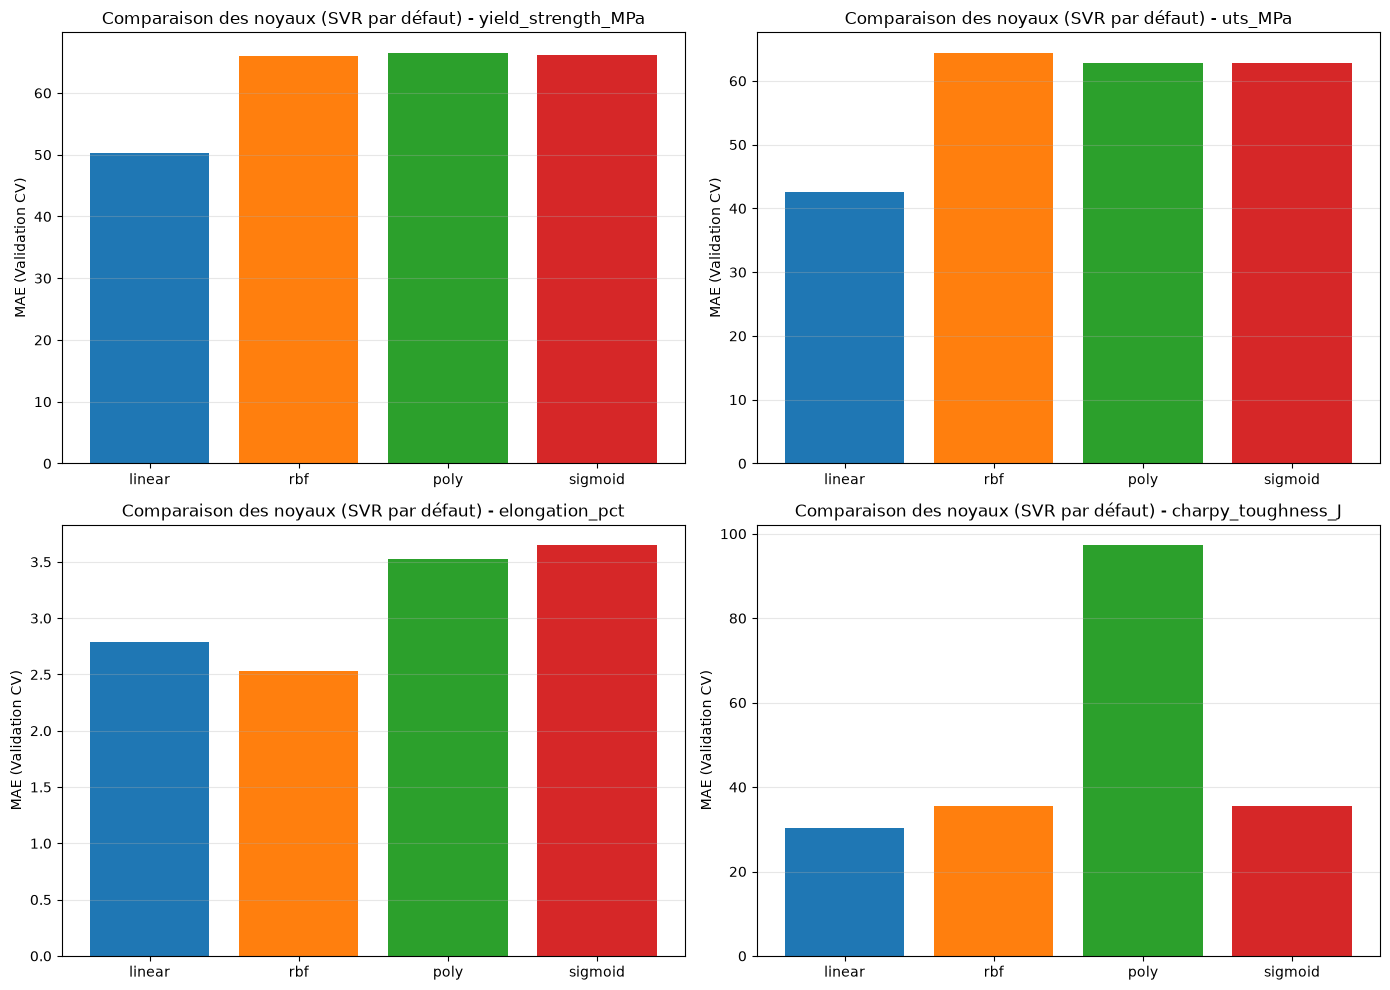

In [7]:
# Extraction des résultats comparatifs par noyau à partir des logs du GridSearchCV
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, target in enumerate(TARGETS):
    X, y, cv = get_xy(train, target)
    
    kernel_scores = {}
    for kernel in ["linear", "rbf", "poly", "sigmoid"]:
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("svm", SVR(kernel=kernel))
        ])
        scores = cross_validate(pipe, X, y, cv=cv, scoring="neg_mean_absolute_error")
        kernel_scores[kernel] = -scores["test_score"].mean()
        
    ax = axes[idx]
    ax.bar(kernel_scores.keys(), kernel_scores.values(), color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])
    ax.set_title(f"Comparaison des noyaux (SVR par défaut) - {target}")
    ax.set_ylabel("MAE (Validation CV)")
    ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


### 4. Évaluation finale et enregistrement des résultats

In [8]:
results_svm = evaluate("SVM", best_svm_pipelines, train)
results_svm

,model,target,family,n,MAE,RMSE,MAE_std,RMSE_std,n_clf,n_nc,F1_nc,recall_nc
0,SVM,yield_strength_MPa,all,620,32.997168,51.646046,4.622862,10.461118,619,102,0.761364,0.656863
1,SVM,yield_strength_MPa,C-Mn,552,30.555919,45.839130,3.784972,7.565732,552,102,0.761364,0.656863
2,SVM,yield_strength_MPa,CrMo2,30,56.766057,94.644286,49.664692,65.065721,29,0,0.000000,0.000000
3,SVM,yield_strength_MPa,CrMo91,38,49.694603,76.970917,23.787189,35.238892,38,0,0.000000,0.000000
4,SVM,uts_MPa,all,596,27.400035,45.335333,4.187095,11.179472,595,198,0.742515,0.626263
5,SVM,uts_MPa,C-Mn,531,25.021377,37.505516,2.793021,4.803502,531,198,0.742515,0.626263
6,SVM,uts_MPa,CrMo2,34,52.337256,91.380731,42.169646,61.244879,33,0,0.000000,0.000000
7,SVM,uts_MPa,CrMo91,31,40.793637,79.128516,24.870057,47.860227,31,0,0.000000,0.000000
8,SVM,elongation_pct,all,558,1.831876,2.569984,0.206596,0.517078,557,48,0.636364,0.583333
9,SVM,elongation_pct,C-Mn,497,1.736294,2.298108,0.076248,0.109287,497,37,0.735294,0.675676


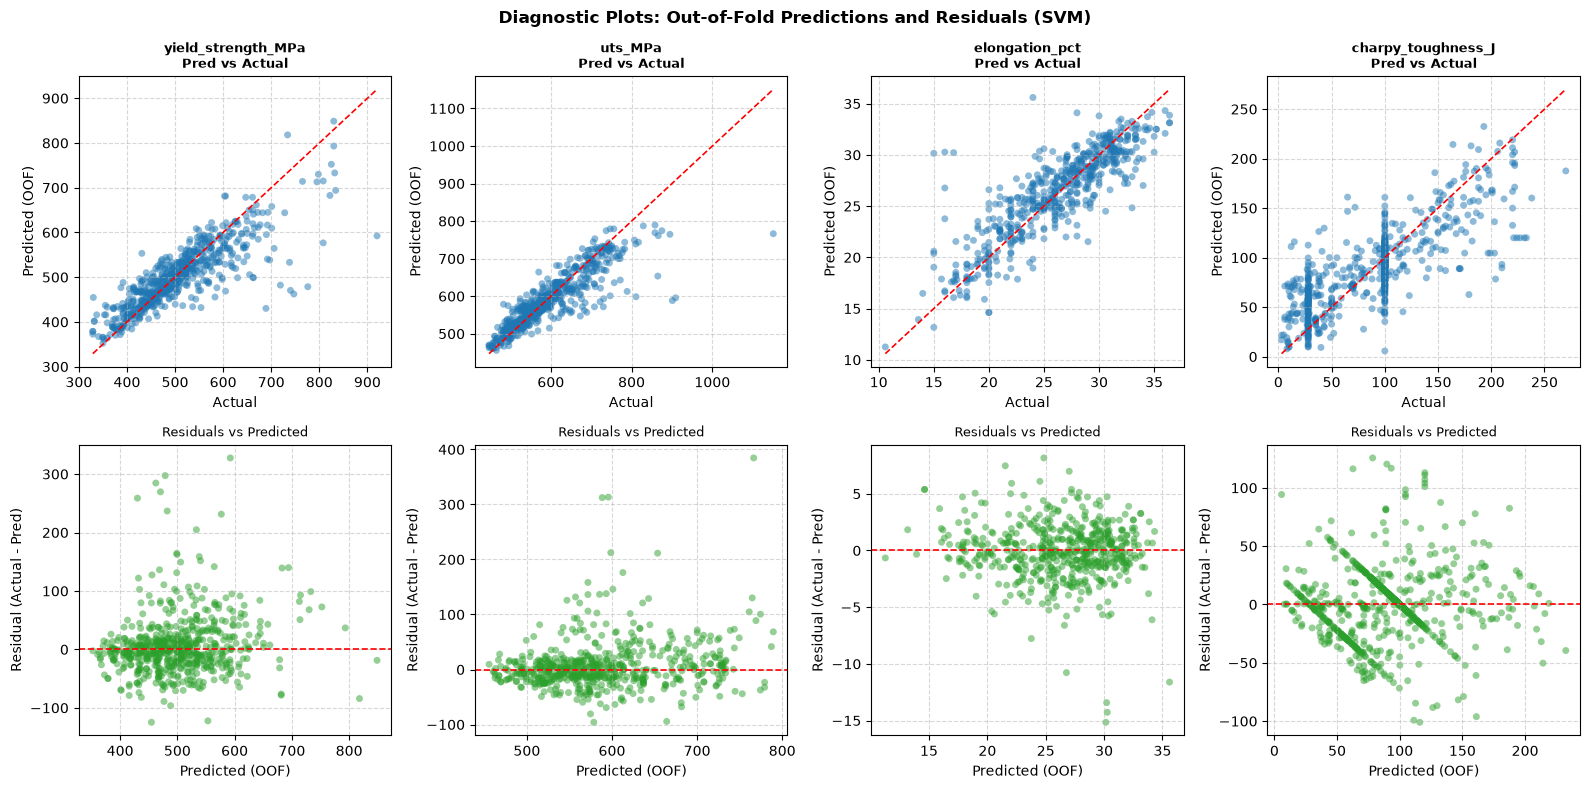

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, target in enumerate(TARGETS):
    X, y, _ = get_xy(train, target)
    oof_fwd = oof_predict(best_svm_pipelines[target], train, target)
    y_val = y.loc[oof_fwd.index]
    pred = oof_fwd["pred"]
    resids = y_val - pred
    
    ax_sc = axes[0, i]
    ax_sc.scatter(y_val, pred, alpha=0.5, edgecolors="none", s=25, color="#1f77b4")
    min_v, max_v = min(y_val.min(), pred.min()), max(y_val.max(), pred.max())
    ax_sc.plot([min_v, max_v], [min_v, max_v], "r--", linewidth=1.2)
    ax_sc.set_title(f"{target}\nPred vs Actual", fontsize=9, fontweight="bold")
    ax_sc.set_xlabel("Actual")
    ax_sc.set_ylabel("Predicted (OOF)")
    ax_sc.grid(True, linestyle="--", alpha=0.5)
    
    ax_res = axes[1, i]
    ax_res.scatter(pred, resids, alpha=0.5, edgecolors="none", s=25, color="#2ca02c")
    ax_res.axhline(0, color="r", linestyle="--", linewidth=1.2)
    ax_res.set_title("Residuals vs Predicted", fontsize=9)
    ax_res.set_xlabel("Predicted (OOF)")
    ax_res.set_ylabel("Residual (Actual - Pred)")
    ax_res.grid(True, linestyle="--", alpha=0.5)

fig.suptitle("Diagnostic Plots: Out-of-Fold Predictions and Residuals (SVM)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


In [10]:
results = save_results(results_svm)
models_to_compare = [
    "Baseline (mean)",
    "Linear regression",
    "Linear regression (forward)",
    "Linear regression (backward)",
    "PCR",
    "Pruned CART",
    "Bagging",
    "Random forest",
    "Extra-Trees",
    "kNN regression",
    "Naive bayesian",
    "Bayesian Ridge",
    "SVM"
]
compared = results[results["model"].isin(models_to_compare) & (results["family"] == "all")].set_index(["model", "target"])

print("--- Regression Metrics (MAE & RMSE) ---")
display(compared[["MAE", "RMSE"]].unstack().reindex(index=models_to_compare).reindex(columns=TARGETS, level="target").round(2))

print("\n--- Classification Metrics (F1_nc & recall_nc) ---")
display(compared[["F1_nc", "recall_nc"]].unstack().reindex(index=models_to_compare).reindex(columns=TARGETS + ["label"], level="target").round(2))

--- Regression Metrics (MAE & RMSE) ---


MAE                         \
target                       yield_strength_MPa uts_MPa elongation_pct   
model                                                                    
Baseline (mean)                           72.57   73.45           4.01   
Linear regression                         52.02   45.13           2.79   
Linear regression (forward)               50.26   42.43           2.72   
Linear regression (backward)              50.30   42.26           2.69   
PCR                                       51.84   44.55           2.78   
Pruned CART                               48.24   41.78           2.60   
Bagging                                   35.24   30.86           1.95   
Random forest                             33.95   29.55           1.94   
Extra-Trees                               29.08   25.24           1.78   
kNN regression                            39.48   34.02           2.16   
Naive bayesian                            60.62   50.13           3.21   
Bayesian Ridge                            51.92   44.64           2.79   
SVM                                       33.00   27.40           1.83   

                                                              RMSE          \
target                       charpy_toughness_J yield_strength_MPa uts_MPa   
model                                                                        
Baseline (mean)                           39.89              94.41   92.19   
Linear regression                         30.36              69.67   63.01   
Linear regression (forward)               25.14              67.34   59.00   
Linear regression (backward)              25.29              67.36   58.88   
PCR                                       30.36              69.50   62.74   
Pruned CART                               18.87              66.22   59.97   
Bagging                                   19.11              49.40   44.45   
Random forest                             19.09              47.46   42.30   
Extra-Trees                               17.37              42.49   38.84   
kNN regression                            18.04              58.49   52.05   
Naive bayesian                            33.68              82.67   69.17   
Bayesian Ridge                            30.33              69.76   62.00   
SVM                                       22.02              51.65   45.34   

                                                                
target                       elongation_pct charpy_toughness_J  
model                                                           
Baseline (mean)                        4.85              51.73  
Linear regression                      3.60              58.54  
Linear regression (forward)            3.50              32.11  
Linear regression (backward)           3.47              31.99  
PCR                                    3.57              58.54  
Pruned CART                            3.32              32.46  
Bagging                                2.51              28.16  
Random forest                          2.51              28.39  
Extra-Trees                            2.36              27.71  
kNN regression                         2.93              34.11  
Naive bayesian                         4.09              50.11  
Bayesian Ridge                         3.62              57.32  
SVM                                    2.57              31.32


--- Classification Metrics (F1_nc & recall_nc) ---


F1_nc                         \
target                       yield_strength_MPa uts_MPa elongation_pct   
model                                                                    
Baseline (mean)                            0.00    0.00           0.00   
Linear regression                          0.45    0.57           0.31   
Linear regression (forward)                0.35    0.60           0.30   
Linear regression (backward)               0.40    0.60           0.30   
PCR                                        0.43    0.60           0.29   
Pruned CART                                0.60    0.64           0.46   
Bagging                                    0.68    0.67           0.62   
Random forest                              0.63    0.68           0.59   
Extra-Trees                                0.78    0.74           0.72   
kNN regression                             0.70    0.66           0.58   
Naive bayesian                             0.53    0.50           0.07   
Bayesian Ridge                             0.36    0.56           0.29   
SVM                                        0.76    0.74           0.64   

                                                               recall_nc  \
target                       charpy_toughness_J label yield_strength_MPa   
model                                                                      
Baseline (mean)                            0.00  0.00               0.00   
Linear regression                          0.65  0.52               0.33   
Linear regression (forward)                0.67  0.58               0.25   
Linear regression (backward)               0.75  0.59               0.28   
PCR                                        0.65  0.53               0.31   
Pruned CART                                0.52  0.77               0.60   
Bagging                                    0.17  0.81               0.57   
Random forest                              0.26  0.76               0.48   
Extra-Trees                                0.27  0.84               0.65   
kNN regression                             0.78  0.78               0.69   
Naive bayesian                             0.36  0.64               0.75   
Bayesian Ridge                             0.65  0.52               0.25   
SVM                                        0.64  0.73               0.66   

                                                                              
target                       uts_MPa elongation_pct charpy_toughness_J label  
model                                                                         
Baseline (mean)                 0.00           0.00               0.00  0.00  
Linear regression               0.47           0.23               0.55  0.39  
Linear regression (forward)     0.49           0.23               0.52  0.43  
Linear regression (backward)    0.49           0.23               0.62  0.45  
PCR                             0.49           0.21               0.55  0.40  
Pruned CART                     0.63           0.50               0.62  0.81  
Bagging                         0.56           0.50               0.10  0.72  
Random forest                   0.54           0.44               0.17  0.64  
Extra-Trees                     0.61           0.60               0.17  0.72  
kNN regression                  0.63           0.48               0.86  0.77  
Naive bayesian                  0.41           0.04               0.38  0.71  
Bayesian Ridge                  0.44           0.21               0.55  0.37  
SVM                             0.63           0.58               0.52  0.58